In [ ]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator
import time

In [113]:
load_dotenv()

True

In [114]:
essay ="""

The current war between the United States and Iran, which officially erupted on February 28, 2026, has precipitated a dramatic geopolitical and economic restructuring of the Middle East[1][2]. Initiated by a massive joint preemptive strike by the United States and Israel[1], the conflict stems from years of festering animosity over Iran’s nuclear program, its regional proxy networks, and subsequent retaliatory escalations[3][4]. As of late April 2026, the two sides remain locked in a fragile "grey zone" standoff following a temporary ceasefire, with high-stakes, yet stalled, peace talks currently underway in Islamabad, Pakistan[5][6].
Prelude and the Road to War
The immediate catalyst for the 2026 war lay in the diplomatic collapses and internal unrest that characterized 2025 and early 2026[1][4]. Despite multiple attempts to renegotiate a framework for Iran's nuclear program following the demise of the Joint Comprehensive Plan of Action (JCPOA), talks in Oman repeatedly failed to produce an agreement[1][4]. Concurrently, the Iranian government faced massive anti-government protests in 2025 and 2026, leading to severe crackdowns and international condemnation[1].
Against this backdrop, the administration of U.S. President Donald Trump, alongside Vice President J.D. Vance and Secretary of State Marco Rubio, alleged that Iran was aggressively expanding its nuclear and ballistic missile capabilities, positioning itself just "a week away" from acquiring bomb-making material[1]. Emboldened by Iran's weakened domestic posture and following a brief 12-day war between Israel and Iran in June 2025, the U.S. initiated the largest military buildup in the region since the 2003 invasion of Iraq[1][4].
Operation Epic Fury and Iranian Retaliation
On February 28, 2026, the conflict officially escalated from proxy skirmishes into direct, kinetic warfare[2][4]. The United States and Israel launched "Operation Epic Fury," executing nearly 900 airstrikes within a 12-hour window against Iranian military bases, air defenses, and government facilities[2][4]. The opening salvo succeeded in its decapitation objective: it assassinated Iran's Supreme Leader, Ali Khamenei, along with the commander of the Islamic Revolutionary Guard Corps (IRGC) and the nation's defense minister[1][7]. Mojtaba Khamenei was swiftly appointed as his father's successor[1][3].
Iran’s response was immediate and sweeping. In a bid to exact heavy costs, Iran unleashed hundreds of ballistic missiles and thousands of drones targeting Israel, U.S. military installations, and U.S.-allied Arab states, including Saudi Arabia, the UAE, Bahrain, Qatar, and Kuwait[1][4][7]. The retaliatory strikes targeted both military infrastructure and vital oil and gas facilities, causing significant regional casualties and displacing millions, heavily affecting neighboring Lebanon as well[4][7].
Economic Disruption and the Strait of Hormuz
One of the most devastating global consequences of the war has been the severe disruption of international maritime trade[1][8]. Iran capitalized on its strategic geography by closing the Strait of Hormuz, an essential chokepoint for the world's oil and gas[8]. The blockade triggered an immediate energy crisis, fueling shortages in Asia and pushing Brent crude oil prices to nearly $108 a barrel by late April[4][9].
In retaliation, the United States imposed a strict counter-blockade on April 13, 2026, targeting any vessels bound for Iranian ports[8]. The U.S. Central Command (CENTCOM) recently reported intercepting and redirecting at least 38 vessels to enforce the naval blockade, successfully cutting off vital revenue streams for Tehran[10]. The U.S. military has also essentially neutralized Iran’s conventional naval forces, though the IRGC's fast-attack boats and the threat of underwater mines remain persistent dangers in the Gulf[6][11].
Current Geopolitical Standoff and Diplomatic Efforts
Following five weeks of devastating conflict, a temporary ceasefire was implemented on April 7–8, 2026, facilitating the first direct negotiations between Washington and Tehran since 1979[4][12]. With Pakistan acting as the mediator, delegations converged in Islamabad to hammer out a lasting peace[12]. However, the talks have encountered severe speed bumps[9].
The U.S. demands "zero enrichment" of nuclear material, the dismantling of Iran's ballistic missile program, and an immediate end to Tehran’s funding of regional proxy groups like Hezbollah and Hamas[3]. Conversely, Iran demands the lifting of the U.S. naval blockade, massive reparations for the February strikes, and security guarantees before it reopens the Strait of Hormuz[5][9].
As of late April 2026, a sense of deadlock prevails[6]. President Trump recently canceled his special envoys' (Steve Witkoff and Jared Kushner) planned trip to Pakistan, citing dissatisfaction with Iran's diplomatic proposals and asserting that U.S. military pressure has left Iran in "really bad shape"[6][9][11]. Meanwhile, Iranian Foreign Minister Abbas Araghchi has sought to bolster alliances elsewhere, conducting high-level discussions in Oman and traveling to Saint Petersburg to meet with Russian President Vladimir Putin, indicating a potential pivot to non-Western powers for leverage[6][10].
Conclusion
The 2026 war between the U.S. and Iran has fundamentally fractured the strategic equilibrium of West Asia[2]. What began as a targeted U.S.-Israeli decapitation strike has devolved into an economic and military war of attrition[2][5]. With global energy markets destabilized, the Strait of Hormuz effectively closed, and peace talks in Islamabad stalling over inflexible demands, the conflict remains a volatile flashpoint[5][6][8]. Whether the current ceasefire holds or shatters into a broader regional war will depend heavily on the next moves brokered in Islamabad and the resilience of both nations against mounting economic and political pressure[5][9].
"""

In [115]:
class EvaluationSchema(BaseModel):
    feedback : str = Field(description="Detailed feedback on the essay.")
    score :  int = Field(description="Score out of 10 for the essay.", ge = 0, le = 10)

In [ ]:
# structured_model = ChatGoogleGenerativeAI.with_structured_output(model="gemini-2.5-flash", temperature=0.2, schema=EvaluationSchema, self=ChatGoogleGenerativeAI)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)
structured_model = model.with_structured_output(schema=EvaluationSchema)


NotImplementedError: with_structured_output is not implemented for this model.

In [ ]:
# define state
class EvaluateEssayState(TypedDict):
    essay: str
    evaluate_clarity: str
    evaluate_analysis: str
    evaluate_language: str
    overall_evaluation: str
    individual_scores: Annotated[list[int], operator.add]


In [ ]:
graph =  StateGraph(EvaluateEssayState) 

In [ ]:
def evaluate_clarity(state: EvaluateEssayState) -> StateGraph:
    prompt = f"""
Evaluate the clarity of the following essay. Provide a score from 1 to 10, where 1 is very unclear and 10 is very clear. \n Essay: {state['essay']}
"""
    response = structured_model.invoke(prompt)
    time.sleep(2)  # Simulate processing time
    
    return {"evaluate_clarity": response.feedback, "individual_scores": [response.score]}

In [ ]:
def evaluate_analysis(state: EvaluateEssayState):
    prompt = f"""
Evaluate the depth of analysis in the following essay. Provide a score from 1 to 10, where 1 is very shallow and 10 is very deep. \n Essay: {state['essay']}
"""
    response = structured_model.invoke(prompt)
    time.sleep(2)  # Simulate processing time
    return {"evaluate_analysis": response.feedback, "individual_scores": [response.score]}

In [ ]:
def evaluate_language(state: EvaluateEssayState):
    prompt = f"""Evaluate the use of language in the following essay. Provide a score from 1 to 10, where 1 is very poor and 10 is excellent. \n Essay: {state['essay']}
"""
    response = structured_model.invoke(prompt)
    time.sleep(2)  # Simulate processing time
    return {"evaluate_language": response.feedback, "individual_scores": [response.score]}

In [ ]:
def overall_evaluation(state: EvaluateEssayState):
    # summarized feedback from previous evaluations
    prompt = f"""
        Based on the following feedbacks, \n {state['evaluate_clarity']}, \n {state['evaluate_analysis']}, \n {state['evaluate_language']}, provide a summary of the essay. 
"""
    response = model.invoke(prompt)
    time.sleep(2)  # Simulate processing time
    # return {"overall_evaluation": response.content}

    # average score
    average_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {"overall_evaluation": response.content, "average_score": average_score}

In [ ]:
# Add nodes
graph.add_node(evaluate_clarity)
graph.add_node(evaluate_analysis)
graph.add_node(evaluate_language)
graph.add_node(overall_evaluation)

In [ ]:
# Add edges
graph.add_edge(START, "evaluate_clarity")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_language")

graph.add_edge("evaluate_clarity", "overall_evaluation")
graph.add_edge("evaluate_analysis", "overall_evaluation")
graph.add_edge("evaluate_language", "overall_evaluation")

graph.add_edge("overall_evaluation", END)



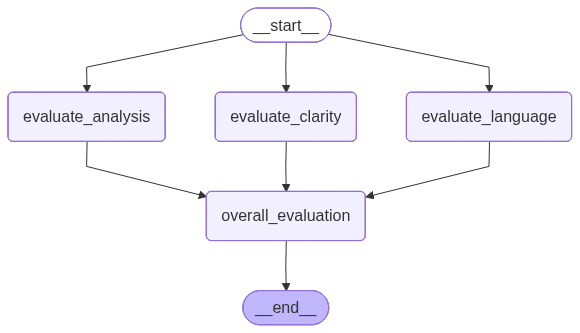

In [ ]:
workflow = graph.compile()
workflow

In [ ]:
initial_state = {"essay": essay}
final_state = workflow.invoke(initial_state)
print(final_state)

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 34.017193002s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_d

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 31.69423305s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 31
}
]